In [114]:
! pip -q install matplotlib
! pip -q install seaborn


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [115]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [116]:


def load_and_align_jsonl(directory: str, strict: bool = True) -> pd.DataFrame:
    """
    Reads all .jsonl files in a directory and aligns data by 'id'.
    Each file's distances will appear in its own column.
    Validates that all files contain the same set of ids.

    Parameters
    ----------
    directory : str
        Path to the folder containing .jsonl files.
    strict : bool
        If True, raises ValueError when id sets differ.
        If False, logs a warning and continues (outer join).

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by 'id', with one column per file of distances.
    """
    dataframes = []
    expected_ids = None

    for filename in sorted(os.listdir(directory)):
        if filename.endswith(".jsonl"):
            filepath = os.path.join(directory, filename)
            
            # Read jsonl file
            df = pd.read_json(filepath, lines=True, dtype={"idx": int, "distance": float})
            df.rename(columns={"idx":"id"}, inplace=True)
            print(df.head())
            df = df[["id", "distance"]].set_index("id")
            
            print("validating ids")
            # Validate IDs
            current_ids = set(df.index)
            if expected_ids is None:
                expected_ids = current_ids
            else:
                if current_ids != expected_ids:
                    missing = expected_ids - current_ids
                    extra   = current_ids - expected_ids
                    
                    report = [f"File {filename} has mismatched ids:"]
                    if missing:
                        report.append(f"  Missing ids: {sorted(missing)}")
                    if extra:
                        report.append(f"  Extra ids: {sorted(extra)}")
                    report_msg = "\n".join(report)

                    if strict:
                        raise ValueError(report_msg)
                    else:
                        print("WARNING:\n" + report_msg)
            
            # Rename distance column to filename (without extension)
            colname = os.path.splitext(filename)[0]
            df = df.rename(columns={"distance": colname})
            
            dataframes.append(df)

    if not dataframes:
        return pd.DataFrame()

    # If strict=True, all id sets match => safe to concatenate
    merged = pd.concat(dataframes, axis=1).sort_index()
    return merged





In [117]:
data_type="synthetic2"
directory = f"bubbledata/{data_type}/"  # change this
df = load_and_align_jsonl(directory, strict=True)
print(df.head())
#df.to_csv("aligned_distances.csv")

   id                                    final_inversion  distance
0   0  in "The New Year's Gala Ball". Dr. P. F. Allan...  0.000000
1   1  in Dr. P. W. Orr.'s "Queen Gala". The Allylpar...  0.081500
2   2  in Dr. W. F. W. Everett's "Pimp or Tail". The ...  0.014500
3   3                            in F. R. R.              0.012500
4   4  in New York. Dr. R. R. P. Felton's Parataxise ...  0.047499


validating ids
   id                                    final_inversion  distance
0   0  of Human Origins, Ancient Greeks, Ancient Turk...    0.0000
1   1  of Human Origins, Ancient Greeks, Ancient Turk...    0.0050
2   2  of Human Origins, Ancient Greeks, Ancient Turk...    0.0015
3   3  of Human Origins, Ancient Greeks, Ancient Turk...    0.0070
4   4  of Ancient Greeks, Last March, Antiocean Greek...    0.0045
validating ids
   id                                    final_inversion  distance
0   0  Oklahoma, the day was a Saturday attempt at th...    0.0000
1   1  Oklahoma, the total was $17.8. The challenge t...    0.0035
2   2  Oklahoma, the claim was made that the day was ...    0.0015
3   3  Syracuse One was a Saturday attempt at the Nat...    0.0025
4   4  Oklahoma, the claim was made that the day was ...    0.0030
validating ids
   id           final_inversion  distance
0   0   1               All men    0.0000
1   1              LSF on the      0.0180
2   2                   

[ 0.08150016  0.00500001  0.00349995  0.01799977  0.00900002  0.02300005
  0.01399982  0.0015      0.03799976  0.04699957  0.01949975  0.03700005
  0.01650003  0.00949988  0.03000002  0.04350002  0.03899999  0.00999987
  0.00899988  0.01599979  0.00099999  0.01149985  0.04599987  0.07600008
  0.02350005  0.00049999  0.00049999  0.0015      0.011       0.02549967
  0.01599998  0.0475001   0.01750004  0.02049999  0.03300003  0.03050006
  0.005       0.02199972  0.0005      0.01050002  0.00699999  0.008
  0.01150002  0.00850002  0.01900004  0.02149972  0.0079999   0.01799977
  0.00550001  0.00549993  0.00849989  0.0395      0.00949988  0.01299983
  0.03200001  0.00600001  0.01200002  0.02050004  0.0015      0.01600003
  0.00899999  0.02849963  0.01150002  0.01000002  0.02000004 -0.01549998
 -0.00550001 -0.02799964 -0.03649953 -0.00950002 -0.02450005 -0.0154998
 -0.03500007 -0.08299893 -0.00900002 -0.0079999  -0.05599996 -0.00600001
 -0.02049974 -0.001      -0.00850001 -0.014      -0.00999

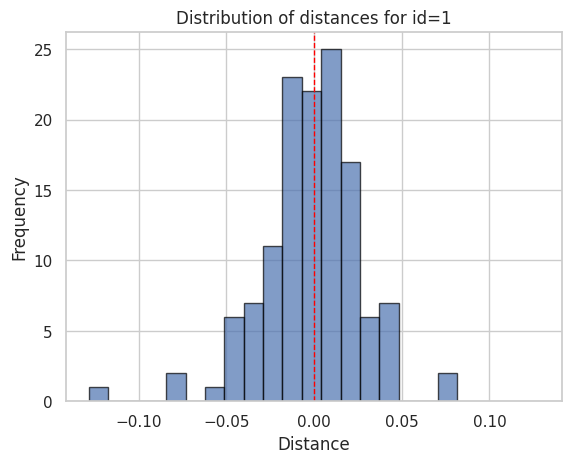

In [118]:
def get_double_sided_values(df, id_value):
    values = df.loc[id_value].dropna().values  # drop NaN just in case
    values_neg = df.loc[-id_value].dropna().values
    values = np.concatenate((values, -1*values_neg))
    return values

def plot_id_distribution(df, id_value):
    """
    Plots a histogram of all values across files for a given id.
    """
    if id_value not in df.index:
        raise ValueError(f"id {id_value} not found in DataFrame")
    
    values = get_double_sided_values(df, id_value)
    #values = [0.001, 0.01, 0.043, 0.34, 0.883, 0.343, 0.343, 0.002]  # test
    print(values)
    max_abs = max(abs(values.min()), abs(values.max()))
    
    plt.hist(values, bins='auto', edgecolor='black', alpha=0.7)
    plt.title(f"Distribution of distances for id={id_value}")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.xlim(-max_abs*1.1, max_abs*1.1)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.show()

plot_id_distribution(df, 1)
value_array = [get_double_sided_values(df, i) for i in range(0,768)]
#print(value_array)

In [119]:


from scipy.stats import skew, kurtosis, zscore
from sklearn.ensemble import IsolationForest

import seaborn as sns

# ------------------------
# Function to summarize each distribution
# ------------------------
def summarize_distributions(distributions, z_thresh=3.0):
    summary = []

    for i, dist in enumerate(distributions):
        #print(dist)
        dist = np.array(dist)
        dist = dist[~np.isnan(dist)]  # Remove NaNs

        if len(dist) < 5:
            continue  # Skip very small distributions

        # Basic stats
        mean_val = np.mean(dist)
        median_val = np.median(dist)
        std_val = np.std(dist)
        q1 = np.percentile(dist, 25)
        q3 = np.percentile(dist, 75)
        iqr = q3 - q1
        skew_val = skew(dist)
        kurtosis_val = kurtosis(dist)

        # IQR outliers
        iqr_outliers = ((dist < (q1 - 1.5 * iqr)) | (dist > (q3 + 1.5 * iqr))).sum()

        # Z-score outliers
        if std_val == 0:
            z_outliers = 0
        else:
            z_outliers = (np.abs(zscore(dist)) > z_thresh).sum()

        summary.append({
            "index": i,
            "mean": mean_val,
            "median": median_val,
            "std": std_val,
            "iqr": iqr,
            "skew": skew_val,
            "kurtosis": kurtosis_val,
            "iqr_outliers": iqr_outliers,
            "z_outliers": z_outliers,
            "n": len(dist)
        })

    return pd.DataFrame(summary)

# ------------------------
# Function to detect outlier distributions using Isolation Forest
# ------------------------
def detect_outlier_distributions(summary_df):
    features = summary_df[["mean", "std", "skew", "kurtosis", "iqr_outliers", "z_outliers"]]
    clf = IsolationForest(contamination='auto', random_state=42)
    summary_df["outlier_dist"] = clf.fit_predict(features)
    summary_df["outlier_dist"] = summary_df["outlier_dist"].map({1: 0, -1: 1})
    return summary_df

# ------------------------
# Optional visualization
# ------------------------
def plot_distributions(distributions, outlier_flags):
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 6))
    data = [dist for dist in distributions]
    sns.boxplot(data=data, showfliers=True)
    for i, flag in enumerate(outlier_flags):
        if flag:
            plt.gca().get_xticklabels()[i].set_color('red')
    plt.title("Distributions (Red = Outlier Distribution)")
    plt.xlabel("Distribution Index")
    plt.ylabel("Value")
    plt.show()

# ------------------------
# Example usage
# ------------------------
#if __name__ == "__main__":
    # Simulated data: 50 normal distributions, 5 with outliers
#    np.random.seed(42)
#    distributions = [np.random.normal(0, 1, 100) for _ in range(50)]
#    distributions += [np.concatenate([np.random.normal(0, 1, 95), np.random.normal(10, 1, 5)]) for _ in range(5)]

#    summary_df = summarize_distributions(distributions)
#    summary_df = detect_outlier_distributions(summary_df)

#    print(summary_df.sort_values("outlier_dist", ascending=False)[["index", "outlier_dist", "iqr_outliers", "z_outliers"]])

    # Optional: visualize
#    plot_distributions(distributions, summary_df["outlier_dist"].values)


In [120]:

summary = summarize_distributions(value_array)
summary = detect_outlier_distributions(summary)

In [121]:
print(summary.sort_values("outlier_dist", ascending=False)[["index", "outlier_dist", "iqr_outliers", "z_outliers"]])

     index  outlier_dist  iqr_outliers  z_outliers
0        0             1             0           0
614    614             1             5           2
605    605             1            16           4
180    180             1             9           1
597    597             1             9           2
..     ...           ...           ...         ...
262    262             0            15           3
263    263             0             8           3
264    264             0             8           1
265    265             0            14           4
767    767             0             7           1

[768 rows x 4 columns]


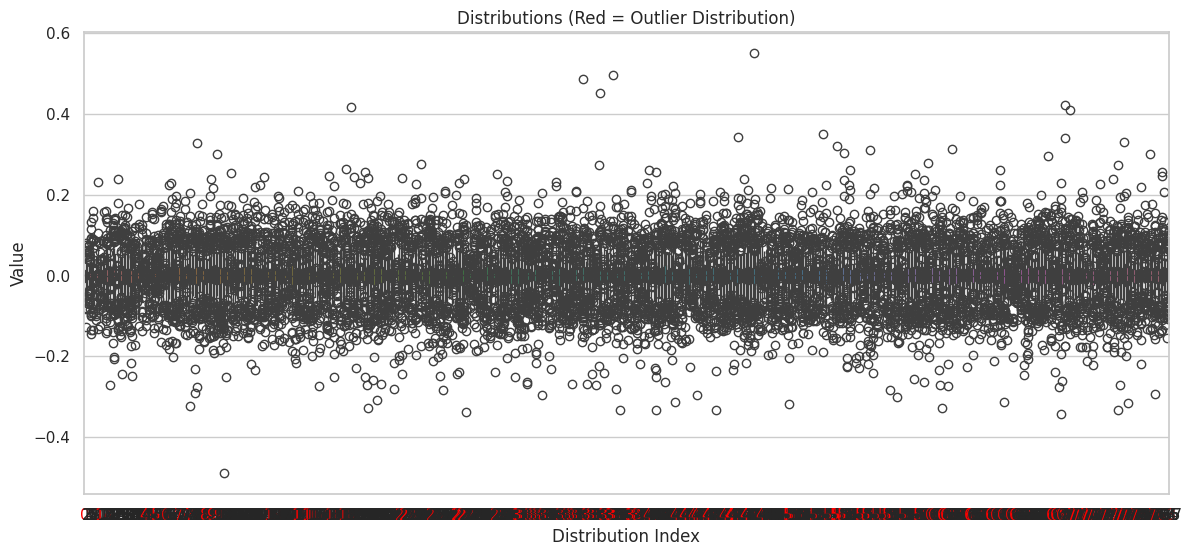

In [122]:
plot_distributions(value_array, summary["outlier_dist"].values)

In [123]:
with open(f"outlier_values_{data_type}.txt", "w") as f:
    f.write(str(summary["outlier_dist"].values.tolist()))

## Synthetic data

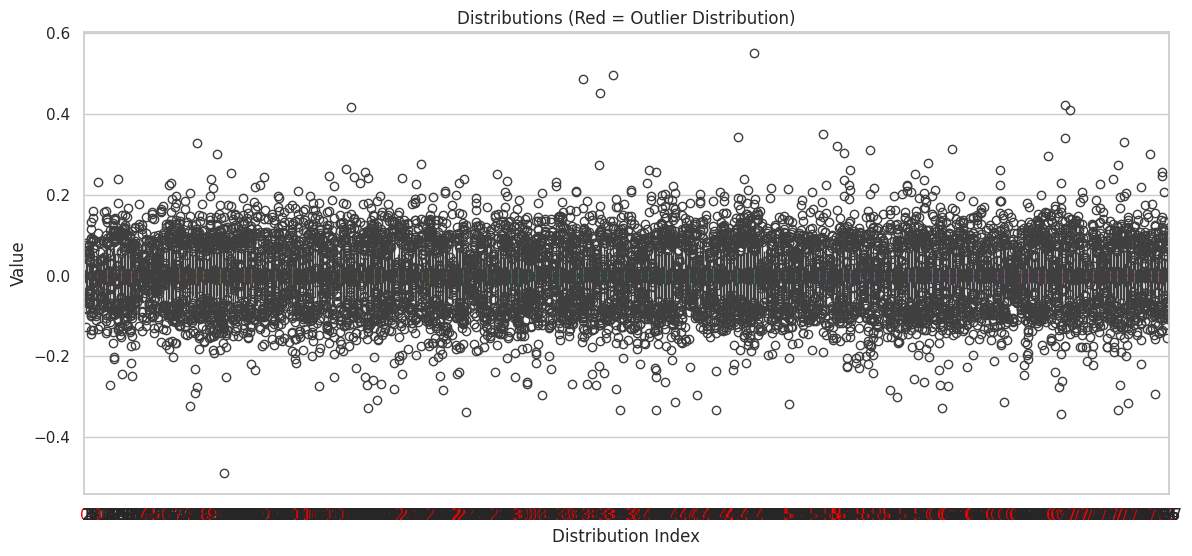

## Real sentences

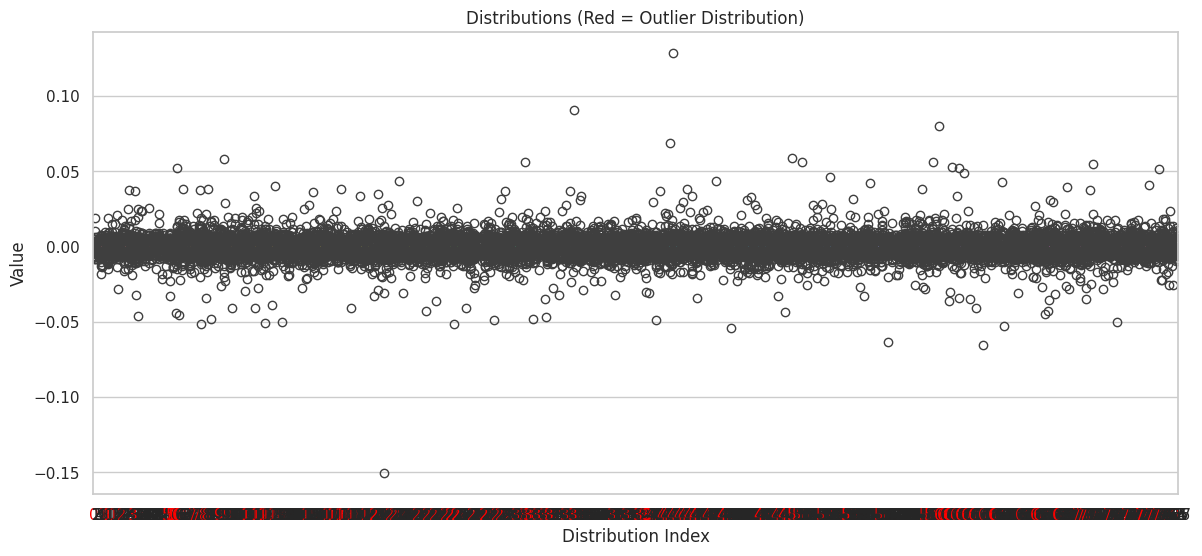